In [1]:
import pandas as pd
import matplotlib.pyplot as plt
orig_df = pd.read_csv('output.csv')

print(orig_df['decode_stage_hit_rate'])

0      0.000028
1      0.041605
2      0.021507
3      0.129124
4      0.021501
         ...   
115    1.000000
116    1.000000
117    1.000000
118    1.000000
119    1.000000
Name: decode_stage_hit_rate, Length: 120, dtype: float64


In [6]:
df = orig_df[orig_df['per_layer_cache'] == False]
print(df['decode_stage_hit_rate'])

0    0.000235
1    0.081121
2    0.128784
3    0.135196
4    0.099159
5    0.092170
6    0.095120
Name: decode_stage_hit_rate, dtype: float64


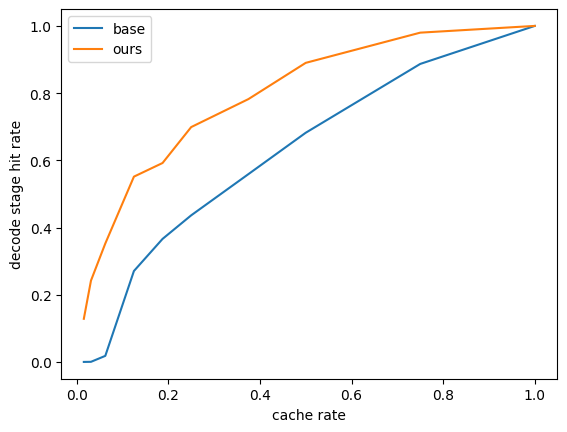

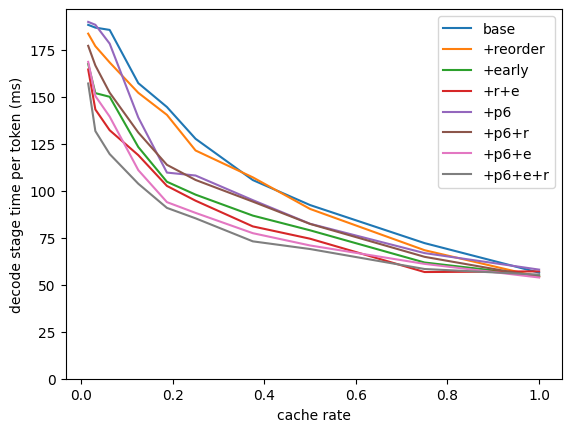

In [10]:
df = orig_df
df = df[df['per_layer_cache'] == True]
# df = df[df['num_predict_expert_per_layer'] == 0]

x = df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['cache_rate']

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['decode_stage_hit_rate'], label='base')
# plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt == False')['decode_stage_hit_rate'], label='+reorder')
# plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt ==  True')['decode_stage_hit_rate'], label='+early')
# plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_hit_rate'], label='+r+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt == False')['decode_stage_hit_rate'], label='+p5')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt == False')['decode_stage_hit_rate'], label='+p5+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt ==  True')['decode_stage_hit_rate'], label='+p5+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_hit_rate'], label='+p5+e+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt == False')['decode_stage_hit_rate'], label='+p6')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt == False')['decode_stage_hit_rate'], label='+p6+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt ==  True')['decode_stage_hit_rate'], label='+p6+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_hit_rate'], label='+p6+e+r')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_hit_rate'], label='ours')
plt.xlabel('cache rate')
plt.ylabel('decode stage hit rate')
plt.legend()
plt.show()

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['decode_stage_forward_time']/1000, label='base')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt == False')['decode_stage_forward_time']/1000, label='+reorder')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='+early')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='+r+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt == False')['decode_stage_forward_time']/1000, label='+p5')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt == False')['decode_stage_forward_time']/1000, label='+p5+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='+p5+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='+p5+e+r')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt == False')['decode_stage_forward_time']/1000, label='+p6')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt == False')['decode_stage_forward_time']/1000, label='+p6+r')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='+p6+e')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='+p6+e+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='ours')
plt.xlabel('cache rate')
plt.ylabel('decode stage time per token (ms)')
plt.ylim(bottom=0)
plt.legend()
plt.show()

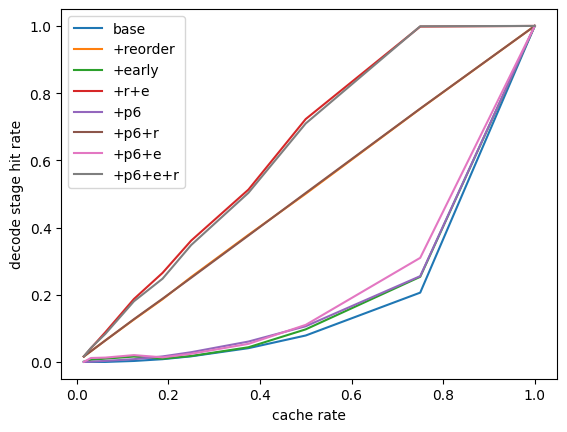

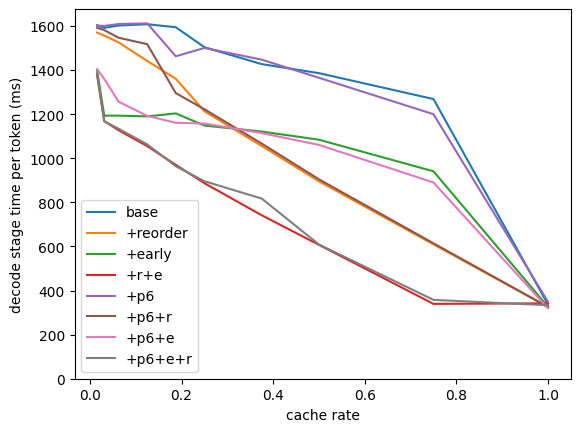

In [13]:
df = orig_df
df = df[df['per_layer_cache'] == True]
# df = df[df['num_predict_expert_per_layer'] == 0]

x = df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['cache_rate']

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['prefill_stage_hit_rate'], label='base')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt == False')['prefill_stage_hit_rate'], label='+reorder')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt ==  True')['prefill_stage_hit_rate'], label='+early')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt ==  True')['prefill_stage_hit_rate'], label='+r+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt == False')['prefill_stage_hit_rate'], label='+p5')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt == False')['prefill_stage_hit_rate'], label='+p5+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt ==  True')['prefill_stage_hit_rate'], label='+p5+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt ==  True')['prefill_stage_hit_rate'], label='+p5+e+r')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt == False')['prefill_stage_hit_rate'], label='+p6')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt == False')['prefill_stage_hit_rate'], label='+p6+r')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt ==  True')['prefill_stage_hit_rate'], label='+p6+e')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['prefill_stage_hit_rate'], label='+p6+e+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['prefill_stage_hit_rate'], label='ours')
plt.xlabel('cache rate')
plt.ylabel('decode stage hit rate')
plt.legend()
plt.show()

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['prefill_stage_forward_time']/1000, label='base')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt == False')['prefill_stage_forward_time']/1000, label='+reorder')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt ==  True')['prefill_stage_forward_time']/1000, label='+early')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('reorder_experts ==  True').query('early_preempt ==  True')['prefill_stage_forward_time']/1000, label='+r+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt == False')['prefill_stage_forward_time']/1000, label='+p5')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt == False')['prefill_stage_forward_time']/1000, label='+p5+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts == False').query('early_preempt ==  True')['prefill_stage_forward_time']/1000, label='+p5+e')
# plt.plot(x, df.query('num_predict_expert_per_layer == 5').query('reorder_experts ==  True').query('early_preempt ==  True')['prefill_stage_forward_time']/1000, label='+p5+e+r')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt == False')['prefill_stage_forward_time']/1000, label='+p6')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt == False')['prefill_stage_forward_time']/1000, label='+p6+r')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts == False').query('early_preempt ==  True')['prefill_stage_forward_time']/1000, label='+p6+e')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['prefill_stage_forward_time']/1000, label='+p6+e+r')
# plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('reorder_experts ==  True').query('early_preempt ==  True')['decode_stage_forward_time']/1000, label='ours')
plt.xlabel('cache rate')
plt.ylabel('decode stage time per token (ms)')
plt.ylim(bottom=0)
plt.legend()
plt.show()

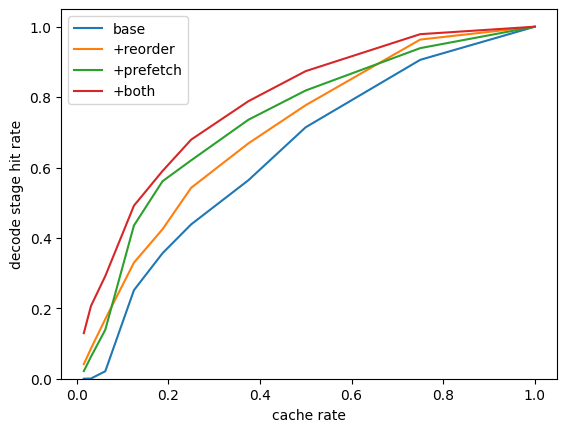

In [52]:
df = orig_df
df = df[df['per_layer_cache'] == True]
x = df.query('num_predict_expert_per_layer == 0 and reorder_experts == False')['cache_rate']


def layer_to_color(idx, length):
  return (idx + 1) / length

subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['decode_stage_hit_rate'], label=f'base')
subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['decode_stage_hit_rate'], label=f'+reorder')
subset = df.query(f'num_predict_expert_per_layer == 6 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['decode_stage_hit_rate'], label=f'+prefetch')
subset = df.query(f'num_predict_expert_per_layer == 5 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['decode_stage_hit_rate'], label=f'+both')

plt.xlabel('cache rate')
plt.ylabel('decode stage hit rate')
plt.ylim(bottom=0)
plt.legend()
plt.show()

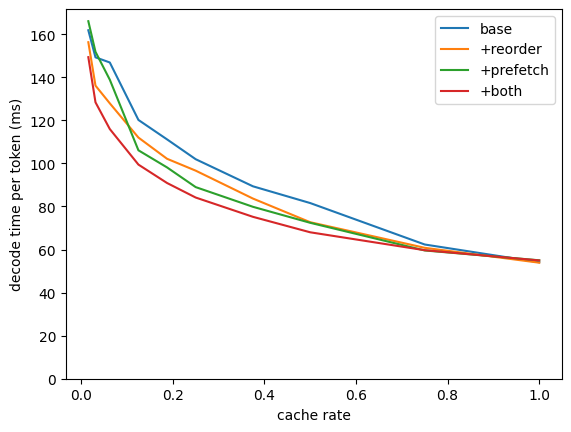

In [49]:
df = orig_df
df = df[df['per_layer_cache'] == True]
x = df.query('num_predict_expert_per_layer == 0 and reorder_experts == False')['cache_rate']


def layer_to_color(idx, length):
  return (idx + 1) / length

subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['decode_stage_forward_time']/1000, label=f'base')
subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['decode_stage_forward_time']/1000, label=f'+reorder')
subset = df.query(f'num_predict_expert_per_layer == 6 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['decode_stage_forward_time']/1000, label=f'+prefetch')
subset = df.query(f'num_predict_expert_per_layer == 5 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['decode_stage_forward_time']/1000, label=f'+both')

plt.xlabel('cache rate')
plt.ylabel('decode time per token (ms)')
plt.ylim(bottom=0)
plt.legend()
plt.show()

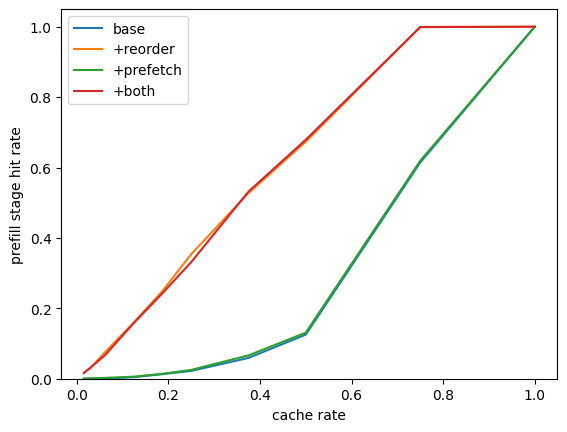

In [50]:
df = orig_df
df = df[df['per_layer_cache'] == True]
x = df.query('num_predict_expert_per_layer == 0 and reorder_experts == False')['cache_rate']


def layer_to_color(idx, length):
  return (idx + 1) / length

subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['prefill_stage_hit_rate'], label=f'base')
subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['prefill_stage_hit_rate'], label=f'+reorder')
subset = df.query(f'num_predict_expert_per_layer == 6 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['prefill_stage_hit_rate'], label=f'+prefetch')
subset = df.query(f'num_predict_expert_per_layer == 5 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['prefill_stage_hit_rate'], label=f'+both')

plt.xlabel('cache rate')
plt.ylabel('prefill stage hit rate')

plt.ylim(bottom=0)
plt.legend()
plt.show()

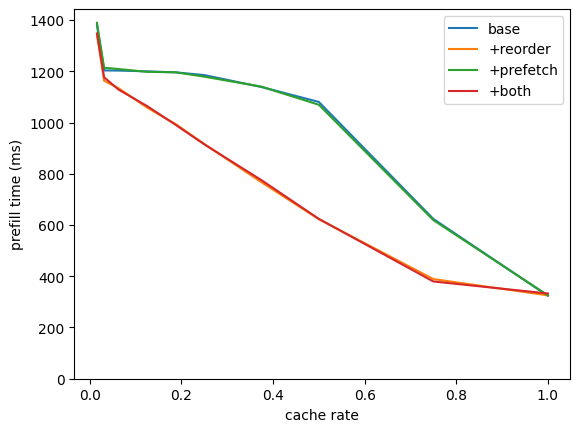

In [51]:
df = orig_df
df = df[df['per_layer_cache'] == True]
x = df.query('num_predict_expert_per_layer == 0 and reorder_experts == False')['cache_rate']


def layer_to_color(idx, length):
  return (idx + 1) / length

subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['prefill_stage_forward_time']/1000, label=f'base')
subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['prefill_stage_forward_time']/1000, label=f'+reorder')
subset = df.query(f'num_predict_expert_per_layer == 6 and reorder_experts == False')
plt.plot(subset['cache_rate'], subset['prefill_stage_forward_time']/1000, label=f'+prefetch')
subset = df.query(f'num_predict_expert_per_layer == 5 and reorder_experts != False')
plt.plot(subset['cache_rate'], subset['prefill_stage_forward_time']/1000, label=f'+both')

plt.xlabel('cache rate')
plt.ylabel('prefill time (ms)')

plt.ylim(bottom=0)
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


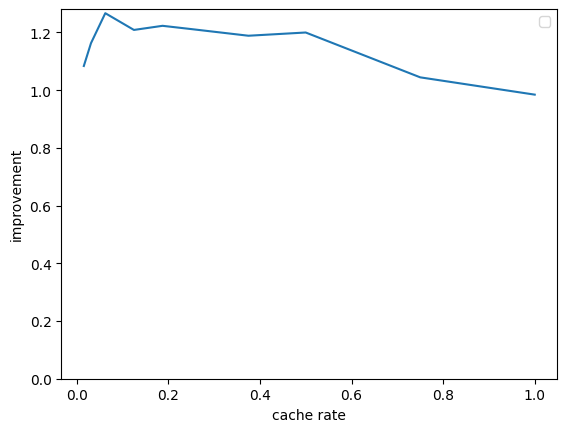

In [57]:
import numpy as np
df = orig_df
df = df[df['per_layer_cache'] == True]
x = df.query('num_predict_expert_per_layer == 0 and reorder_experts == False')['cache_rate']


def layer_to_color(idx, length):
  return (idx + 1) / length

subset = df.query(f'num_predict_expert_per_layer == 0 and reorder_experts == False')
y1 = np.asarray(subset['decode_stage_forward_time']/1000)
subset = df.query(f'num_predict_expert_per_layer == 5 and reorder_experts != False')
y2 = np.asarray(subset['decode_stage_forward_time']/1000)

plt.plot(subset['cache_rate'], y1/y2)
# plt.plot(subset['cache_rate'], y2)


plt.xlabel('cache rate')
plt.ylabel('improvement')
plt.ylim(bottom=0)
plt.legend()
plt.show()